<a href="https://colab.research.google.com/github/mmwaala/Martin_Mwaala/blob/main/Housing_in_Mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

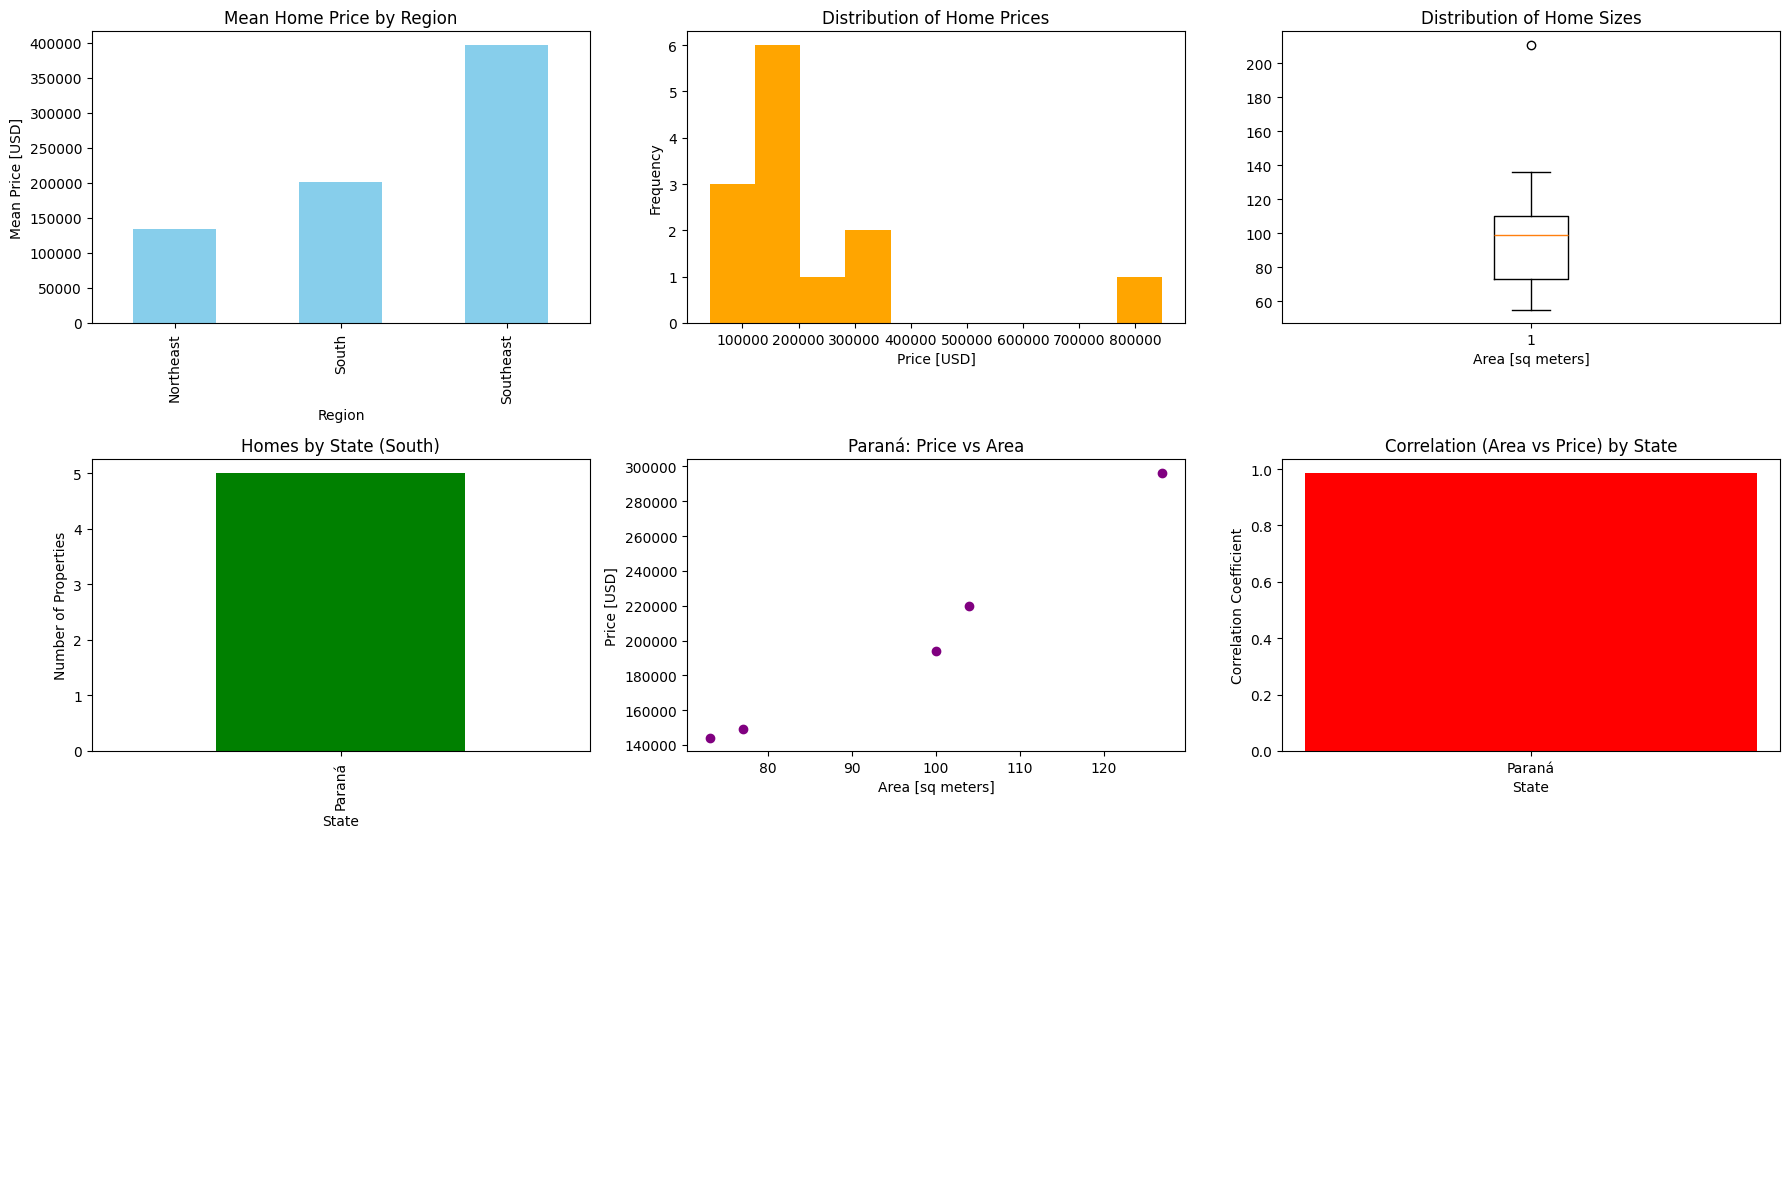

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset as lists (cleaned version based on project instructions)
data = [
    ["apartment", "Northeast", 110.0, 187230.85, -9.644051, -35.708142, "Alagoas"],
    ["apartment", "Northeast", 65.0, 81133.37, -9.643094, -35.70484, "Alagoas"],
    ["house", "Northeast", 211.0, 154465.45, -9.622703, -35.729753, "Alagoas"],
    ["apartment", "Northeast", 99.0, 146013.20, -9.622837, -35.719556, "Alagoas"],
    ["apartment", "Northeast", 55.0, 101416.71, -9.654955, -35.700227, "Alagoas"],
    ["apartment", "Southeast", 72.0, 41422.98, -8.134204, -34.906326, "Pernambuco"],
    ["apartment", "Southeast", 136.0, 848408.53, -8.126664, -34.903924, "Pernambuco"],
    ["apartment", "Southeast", 75.0, 299438.28, -8.125550, -34.907601, "Pernambuco"],
    ["apartment", "South", 127.0, 296448.85, -25.455704, -49.292918, "Paraná"],
    ["apartment", "South", 104.0, 219996.25, -25.455704, -49.292918, "Paraná"],
    ["apartment", "South", 100.0, 194210.50, -25.460236, -49.293812, "Paraná"],
    ["apartment", "South", 77.0, 149252.94, -25.460236, -49.293812, "Paraná"],
    ["apartment", "South", 73.0, 144167.75, -25.460236, -49.293812, "Paraná"],
]

# Define column names
columns = ["property_type", "region", "area_m2", "price_usd", "lat", "lon", "state"]

# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Task 1: Mean home price by region
mean_price_by_region = df.groupby("region")["price_usd"].mean().sort_values(ascending=True)

# Task 2: Histogram of home prices
price_hist_data = df["price_usd"]

# Task 3: Boxplot of home sizes
area_box_data = df["area_m2"]

# Task 4: Homes by state in South
df_south = df.loc[df["region"] == "South"]
homes_by_state = df_south["state"].value_counts()

# Task 5: Scatter plot of Price vs Area for South
largest_state = homes_by_state.idxmax()  # State with most properties
df_south_largest_state = df_south[df_south["state"] == largest_state]

# Task 6: Correlation dictionary for South
south_states_corr = {
    state: df_south[df_south["state"] == state]["area_m2"].corr(
        df_south[df_south["state"] == state]["price_usd"]
    )
    for state in df_south["state"].unique()
}

# Dashboard: 3x3 Layout
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Plot 1: Mean Home Price by Region
mean_price_by_region.plot(
    kind="bar", ax=axes[0, 0], color="skyblue", title="Mean Home Price by Region"
)
axes[0, 0].set_xlabel("Region")
axes[0, 0].set_ylabel("Mean Price [USD]")

# Plot 2: Histogram of Home Prices
axes[0, 1].hist(price_hist_data, bins=10, color="orange")
axes[0, 1].set_title("Distribution of Home Prices")
axes[0, 1].set_xlabel("Price [USD]")
axes[0, 1].set_ylabel("Frequency")

# Plot 3: Boxplot of Home Sizes
axes[0, 2].boxplot(area_box_data)
axes[0, 2].set_title("Distribution of Home Sizes")
axes[0, 2].set_xlabel("Area [sq meters]")

# Plot 4: Homes by State in South
homes_by_state.plot(
    kind="bar", ax=axes[1, 0], color="green", title="Homes by State (South)"
)
axes[1, 0].set_xlabel("State")
axes[1, 0].set_ylabel("Number of Properties")

# Plot 5: Scatter Plot of Price vs Area for Largest State in South
axes[1, 1].scatter(
    df_south_largest_state["area_m2"],
    df_south_largest_state["price_usd"],
    color="purple",
)
axes[1, 1].set_title(f"{largest_state}: Price vs Area")
axes[1, 1].set_xlabel("Area [sq meters]")
axes[1, 1].set_ylabel("Price [USD]")

# Plot 6: Correlation Values for South States
axes[1, 2].bar(
    south_states_corr.keys(), south_states_corr.values(), color="red"
)
axes[1, 2].set_title("Correlation (Area vs Price) by State")
axes[1, 2].set_xlabel("State")
axes[1, 2].set_ylabel("Correlation Coefficient")

# Empty Plots for Unused Cells
axes[2, 0].axis("off")
axes[2, 1].axis("off")
axes[2, 2].axis("off")

# Adjust layout
plt.tight_layout()
plt.show()

